# Event gathering

From the forward model, simply overlay it on a histogram of LTS results. This plot should show clear clusters of rockfall events on the landslide scarp if there are any. Further analysis is my best attempt to filter out these clear rockfall events from background noise.

- Read in LTS data and match it with meteorological data nearest in time, then calculate the corrected velocity at 5 °C.

- Plot a 2D histogram of LTS results by back-azimuth and velocity (corrected for temperature), and overlay outlines of the Barry Arm kinematic zones calculated with `forward_model`.

- Select points within manually defined zone boxes. Further filter within each zone by sigma–tau. The sigma–tau threshold is demonstrated in the next plot.

- Plot a 2D histogram of all LTS points by sigma–tau and MdCCM. Scatter plot the windows within the zone boxes on top.  
  - A side panel shows a KDE histogram of sigma–tau values for the two zones, displaying a clear bimodal distribution.  
  - A threshold is chosen to split the bimodal distribution and preserve the lower sigma–tau events.  
  - Another small plot shows the effect this has on the selected windows—more of the outer-edge windows are removed, further validating this threshold.

- Group windows into events if they are continuous. Plot a small histogram showing the number of windows found in each event.  
  - To further filter events, consider dropping events with only a single window (not used in the final version).

- Get pressure information for each event.

- Plot a time series of events compared to rainfall data and radar data.

- Get pressure for 500 previously selected glacier windows, and plot pressure and MdCCM for both the glacier windows and the zone-selected events.

- Plot PSD of rockfall events and the glacier windows (this plot looks terrible).

- Final plot: an example rockfall event.

In [5]:
#Actual landslide events!
import matplotlib.dates as mdates
import pandas as pd

#df = pd.read_csv("data/lts/BAEI_LTS_results_2025_2026March.csv")
#columns - unnamed:0, index, time, trace_vel, backaz, mdccm, sigtau, datetime
# I am probably not going to include the real LTS data here, since the file is pretty big


#recalculate datetime column, faster than reading it in as a datetime
df['datetime'] = df.Time.apply(mdates.num2date).dt.tz_localize(None) 

import numpy as np

def pd_find_closest_time(
    df1, df2, df1_col="datetime", df2_col="timestamp", df2_feature="airt_c_avg"
):
    """For each row in df1, find the row with the closest time in df2,
    and extract the specified feature and the time difference.

    Returns:
    - A tuple of two lists:
        1. Matched feature values from df2 (e.g., speed of sound)
        2. Time difference in seconds between df1 and matched df2 times

    Example usage:
    df1['C'], df1['C_dt'] = pd_find_closest_time(df1, df2, df2_feature='C')
    """
    #if not df1[df1_col].is_monotonic_increasing:
    #    raise ValueError(f"{df1} must be sorted in ascending order.")

    # Ensure datetime format
    df1 = df1.copy()
    df2 = df2.copy()
    df1[df1_col] = pd.to_datetime(df1[df1_col])
    df2[df2_col] = pd.to_datetime(df2[df2_col])
    # Sort both dataframes by time
    df1 = df1.sort_values(df1_col)
    df2 = df2.sort_values(df2_col)
    # Merge using nearest time
    merged = pd.merge_asof(
        df1,
        df2[[df2_col, df2_feature]],
        left_on=df1_col,
        right_on=df2_col,
        direction="nearest",
        suffixes=("_x", ""),
    )

    time_diff = (merged[df1_col] - merged[df2_col]).dt.total_seconds()
    print(
        f"Merge complete, furthest time matchup is {np.max(time_diff)/60:.2f} min. (if>7.5, updated met data is needed)"
    )

    return merged[df2_feature].to_list(), merged[df2_col].to_list(), time_diff

print("Finding met data to merge")
# read met data from a csv or direct from the dggs site
met_data = "data/bae_metdata.csv"
#Can also read met data directly from  - "https://dggs.alaska.gov/weatherstations/csv/8?"
#met_data_all = "/Users/che/Desktop/usgs/data/bae_metdata.csv"
met_data = pd.read_csv(met_data, parse_dates=[1], date_format='%m/%d/%y %H:%M')
#print(met_data.iloc[-1].timestamp) #print last row to check date/time

df['airt_c_avg'], df['nearest_met_time'], df['met_time_difference_s'] = pd_find_closest_time(df, met_data)
df['vel_corrected_5C'] = df['Trace_vel'] * np.sqrt((273.15+5) / (df['airt_c_avg'] + 273.15))

print( f"windows with not optimal met_data {len( df.loc[ df['met_time_difference_s']/60 > 7.5 ])}" )
print(df.shape)
#df.to_csv("data/lts/BAEI_LTS_results_ALL_wMet.csv", index=False)

Finding met data to merge
Merge complete, furthest time matchup is 3645.00 min. (if>7.5, updated met data is needed)
windows with not optimal met_data 94231
(26154239, 10)


(26154239, 10)
windows after minimal filtering 685847


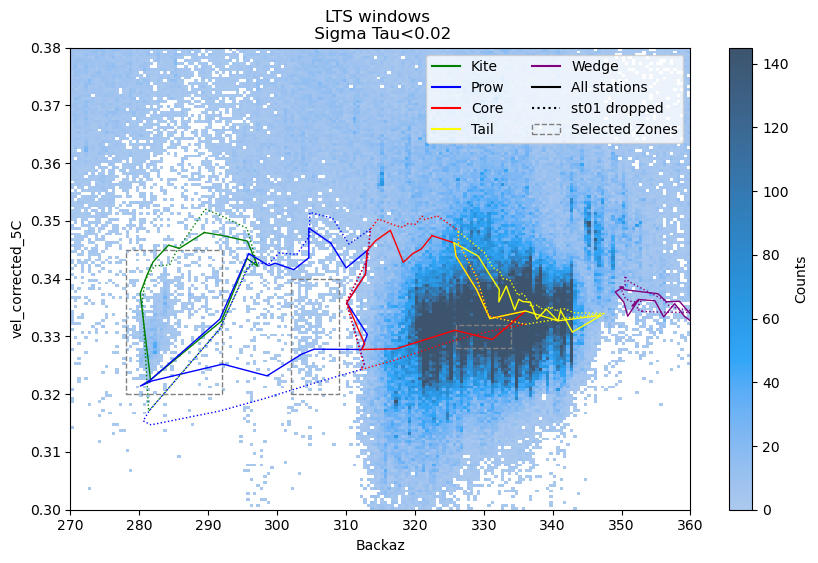

In [17]:
#Test ALL BAEI data (within date range), plot on cartesian, with histogram option
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
import matplotlib.patches as mpatches
import seaborn as sns

df = pd.read_csv("data/lts/BAEI_LTS_results_ALL_wMet.csv")
tdf = df
print(tdf.shape)

# Set up first pass of filters
tdf = df.loc[ (df['Backaz']>270) ] #| (df['Backaz']<10)]
#tdf = tdf.loc[ tdf['datetime'].dt.year.isin([2022,2023, 2024,2025])]
#tdf = tdf.loc[ tdf['datetime'].dt.month.isin( [6, 7,8,9, 10])]
#tdf = tdf.loc[(tdf['MdCCM']>0.2)]
tdf = tdf.loc[ (tdf['Sigma_tau']<0.03)]
print(f"windows after minimal filtering {len(tdf)}" )
#tdf['Backaz_zerocentered'] = ((tdf['Backaz'] + 180) % 360) - 180 # useful for plotting BAIS data

fig,ax = plt.subplots(figsize=(10,6))

#File or files produced from forward_model.ipynb
gfile = "data/BAEI_landslide_AzVel.gpkg"
gfile2= "data/BAEI_landslide_AzVel_ST01_DROPPED.gpkg"
gfiles = [gfile, gfile2]
linestyles = ['-', ':', '--', '-.', (0,(5,1))]  # at least one per gfile
file_labels = ["All stations", "st01 dropped"]
zone_labels_added = set()
file_labels_added = set()
for j, gfile in enumerate(gfiles):
    gdf = gpd.read_file(gfile)
    colrs = ['green', 'blue', 'red', 'yellow', 'purple'] # kinematic zone colors
    ls = linestyles[j]
    flabel = file_labels[j]

    for i, row in enumerate(gdf.itertuples()):
        x, y = row.geometry.exterior.xy
        x = np.array(x)
        x = np.where(x<180, x+360, x)
        #x = np.where(x > 180, x - 360, x)

        # plot actual data
        ax.plot(x, y, c=colrs[i], ls=ls, alpha=1, lw=1)

        #add color legend (zones) once
        if row.zone not in zone_labels_added:
            ax.plot([], [], c=colrs[i], ls='-', label=row.zone)
            zone_labels_added.add(row.zone)

     #add linestyle legend (files) once
    if flabel not in file_labels_added:
        ax.plot([], [], c='k', ls=ls, label=flabel)
        file_labels_added.add(flabel)

sns.histplot(data=tdf, x='Backaz', y='vel_corrected_5C', 
             binrange=((0,360), (0.3,0.4)), binwidth=(0.5, 0.0005),
             cbar=True , cbar_kws={'label':'Counts'}, thresh=1, pmax=0.6)# pthresh=0.0001, pmax=0.5

ax.legend()
ax.set_xlim(270,360)
ax.set_ylim(0.3, 0.38)


xrange, yrange = (278, 292), (0.32, 0.345)
ax.add_patch(mpatches.Rectangle((xrange[0], yrange[0]), xrange[1]-xrange[0], yrange[1]-yrange[0], 
                                fc="none", ec='gray', linestyle='--', label='Selected Zones'))

xrange, yrange = (302, 309), (0.32, 0.34)
ax.add_patch(mpatches.Rectangle((xrange[0], yrange[0]), xrange[1]-xrange[0], yrange[1]-yrange[0], 
                                fc="none", ec='gray', linestyle='--'))

xrange, yrange = (326, 334), (0.328, 0.332)
ax.add_patch(mpatches.Rectangle((xrange[0], yrange[0]), xrange[1]-xrange[0], yrange[1]-yrange[0], 
                                fc="none", ec='gray', linestyle='--'))

ax.set_title('LTS windows \n Sigma Tau<0.02')
ax.legend(ncols=2)


In [2]:
#Get POINTS/windows, in the area of interest by simple boxes
#Apply additional filtering by sigma tau filtering

tdf['label'] = 'other'
xrange, yrange = (278, 292), (0.32, 0.345)
mask = tdf["Backaz"].between(xrange[0], xrange[1]) & tdf['vel_corrected_5C'].between(yrange[0], yrange[1])
tdf.loc[mask, "label"] = "Kite"
ax.add_patch(mpatches.Rectangle((xrange[0], yrange[0]), xrange[1]-xrange[0], yrange[1]-yrange[0], 
                                fc="none", ec='green'))

xrange, yrange = (302, 309), (0.32, 0.34)
mask = tdf["Backaz"].between(xrange[0], xrange[1]) & tdf['vel_corrected_5C'].between(yrange[0], yrange[1])
tdf.loc[mask, "label"] = "Prow"
ax.add_patch(mpatches.Rectangle((xrange[0], yrange[0]), xrange[1]-xrange[0], yrange[1]-yrange[0], 
                                fc="none", ec='orange'))

xrange, yrange = (326, 334), (0.328, 0.332)
mask = tdf["Backaz"].between(xrange[0], xrange[1]) & tdf['vel_corrected_5C'].between(yrange[0], yrange[1])
tdf.loc[mask, "label"] = "Glacier"
ax.add_patch(mpatches.Rectangle((xrange[0], yrange[0]), xrange[1]-xrange[0], yrange[1]-yrange[0], fc="none", ec='red'))


windows = tdf.loc[ tdf['label'].isin([ 'Kite', 'Prow'])]
print(f"{len(windows)} windows satisfying the criteria")
print(f"{len(windows.loc[ windows['met_time_difference_s']/60 > 7.5 ])} windows with bad met data")

#further filter by sigtau
#windows = windows.loc[ (windows['label']=='Prow') | (windows['Sigma_tau']<0.012)] #box 1 cutoff
#windows = windows.loc[ (windows['label']=='Kite') | (windows['Sigma_tau']<0.02)] #box 2 sigTau cutoff

print(windows.shape)
#randomly choose 500 box 3 windows
glacier_windows = tdf.loc[tdf['label'] == 'Glacier'].sample(500)
print(windows.shape)
print(glacier_windows.shape)

#save the glacier windows
#glacier_windows.to_csv("data/500_glacier_windows_wPressure.csv", index=False)

4003 windows satisfying the criteria
8 windows with bad met data
(4003, 11)
(4003, 11)
(500, 11)


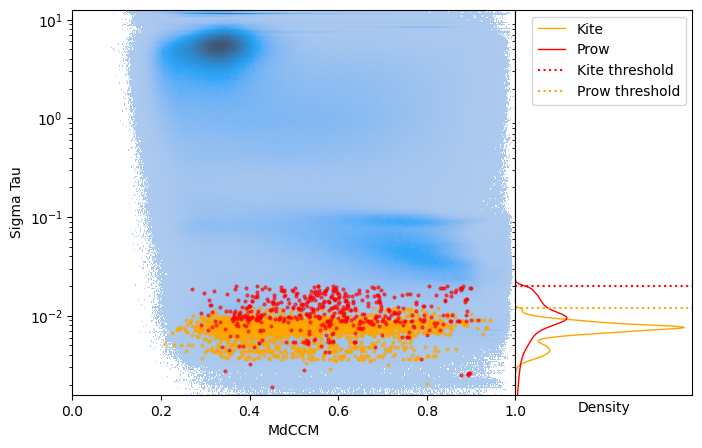

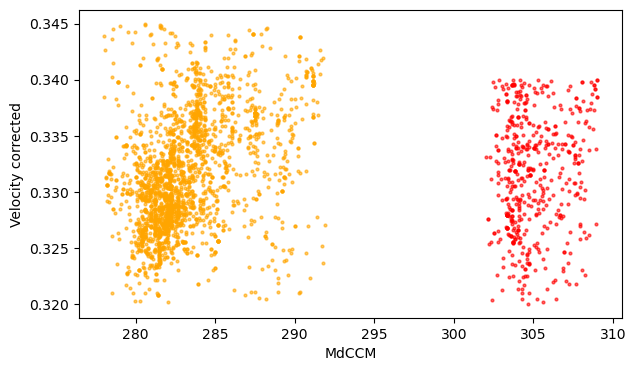

In [16]:
fig,axs = plt.subplots(ncols=2, figsize=(8,5), gridspec_kw={"width_ratios":(5,2)})
sns.histplot(data=df, x='MdCCM', y='Sigma_tau', log_scale=(False, True), ax=axs[0])
#axs[0].legend()


colors=['orange', 'red']
labels = ['Kite', 'Prow']
thresholds = [0.012, 0.02]
for i, label in enumerate(labels):
    subb = windows.loc[windows['label'] == label]

    subb_above = subb.loc[subb['Sigma_tau'] >= thresholds[i]]
    subb_below = subb.loc[subb['Sigma_tau'] < thresholds[i]]

    # Below threshold (filled)
    axs[0].scatter(
        subb_below['MdCCM'],
        subb_below['Sigma_tau'],
        c=colors[i],
        s=4,
        alpha=0.6,
    )

    # Above threshold (outlined)
    axs[0].scatter(
        subb_above['MdCCM'],
        subb_above['Sigma_tau'],
        edgecolors=colors[i],
        facecolors='none',
        s=8,
        alpha=0.8,
        linewidths=0.6,
        marker='o',
    )

    #
    sns.kdeplot(
        y=subb['Sigma_tau'],
        ax=axs[1],
        color=colors[i],
        fill=False,
        alpha=1,
        linewidth=1, label=label)


#axs[0].axhline(0.02, c='red', ls=':') #Highest SigTau from synthetic dataset
#axs[0].axhline(0.012, c='orange', ls=':')
axs[1].axhline(0.02, c='red', ls=':', label='Kite threshold') #Highest SigTau from synthetic dataset
axs[1].axhline(0.012, c='orange', ls=':', label='Prow threshold')
axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[1].legend()
fig.subplots_adjust(wspace=0)
axs[0].set_xlim(0,1)
axs[0].set_xlabel('MdCCM')
axs[0].set_ylabel('Sigma Tau')
axs[1].set_xticks(())
axs[1].set_yticks(())
axs[1].set_xlabel("Density")
axs[1].set_ylabel("")

axs[0].set_ylim(10**-2.8,10**1.1)
axs[1].set_ylim(10**-2.8,10**1.1)
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(7,4))
for i, label in enumerate(labels):
    subb = windows.loc[windows['label'] == label]

    subb_above = subb.loc[subb['Sigma_tau'] >= thresholds[i]]
    subb_below = subb.loc[subb['Sigma_tau'] < thresholds[i]]

    # Below threshold (filled)
    ax.scatter(
        subb_below['Backaz'],
        subb_below['vel_corrected_5C'],
        c=colors[i],
        s=4,
        alpha=0.6,
        label=f"{label} (below)" if i == 0 else None
    )

    # Above threshold (outlined)
    ax.scatter(
        subb_above['Backaz'],
        subb_above['vel_corrected_5C'],
        edgecolors=colors[i],
        facecolors='none',
        s=8,
        alpha=0.8,
        linewidths=0.6,
        marker='o',
        label=f"{label} (above)" if i == 0 else None
    )
ax.set_xlabel('MdCCM')
ax.set_ylabel('Velocity corrected')






#Now apply the additional filtering to the windows
windows = windows.loc[ (windows['label']=='Prow') | (windows['Sigma_tau']<0.012)] #box 1 cutoff
windows = windows.loc[ (windows['label']=='Kite') | (windows['Sigma_tau']<0.02)] #box 2 sigTau cutoff

2931 original windows
2931 windows after thresholding by MdCCM
677 events found
(677, 23)
(677, 23)


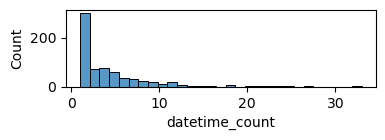

In [22]:

agg_dict = {
    "datetime": [
        "min",
        "max",
        "count",
    ],  # start and end time potentially?
    "Backaz": ["mean", pd.Series.to_list],
    "Trace_vel": [
        "mean",
        pd.Series.to_list,
    ],  # 'is_monotonic_decreasing']
    "MdCCM": [
        "mean",
        "max",
        "min",
        pd.Series.to_list,
    ],
    "Sigma_tau": ["mean", "max", "min", pd.Series.to_list],
    "airt_c_avg":['median'],
    'vel_corrected_5C':['mean', pd.Series.to_list],
    'label':['first', 'last', 'nunique', pd.Series.to_list]}

def detect_events(df, sr, allowable_skips, time_col="Time", mccm_col="MdCCM"):
    """detect events in a dataframe.
       "events" here are considered continous periods with MCCM>threshold.


    Args:
        df (pandas Dataframe): _description_
        sr (integer): sample rate, i.e. time between consecutive samples in seconds
        allowable_skips (int): Number of windows to skip and still group into same event

    Returns:
        _type_: _description_
    """
    # Maybe modify this in the future to accept a single MCCM value below threshold?
    # Could be better to remove the MCCM threshold from the general filtering and do it all here.
    # This also needs to be modified to include 1(var?) point before and after the "event", for purposes
    # of eventually training a LSTM style network on it.

    detections = df.copy()
    detections["Datetime"] = pd.to_datetime(
        detections[time_col]
    )  # assume already in dt format
    # detections["Datetime"] = detections[time_col]
    detections = detections.sort_values("Datetime")
    detections = detections.set_index("Datetime")

    detections["event_id"] = None
    event_number = 1
    current_date = detections.index[0].strftime(
        "%Y%m%d"
    )  # track the current date for resetting event_ids
    event_id = f"{current_date}_{event_number}"
    detections.at[detections.index[0], "event_id"] = event_id  # assign first row

    # Loop through rows (excluding the first row since it already has detection_id)
    for idx in range(1, len(detections)):
        # Check if detections are continuous
        if (detections.index[idx] - detections.index[idx - 1]) <= pd.Timedelta(
            seconds=sr * (1 + allowable_skips)
        ):
            detections.at[detections.index[idx], "event_id"] = event_id
            continue
        else:  # if not continuous, increment detection_number
            event_number += 1

        # Otherwise check if new day
        row_date = detections.index[idx].strftime("%Y%m%d")
        if row_date != current_date:
            current_date = row_date  # Update current_date
            event_number = 1  # Reset number for new day

        # Reconstruct event_number, and assign
        event_id = f"{row_date}_{event_number}"
        detections.at[detections.index[idx], "event_id"] = event_id

    return detections


def group_by_event(
    df,
    sr=4,
    allowable_skips=1,
    agg_dict=None,
    thresh=0.75,
    mccm_col="MdCCM",
    time_col="Time",
):
    """Group rows with the same 'event_id' together, and aggregate statistics for other columns

    Args:
        df (pandas DataFrame): df with event_id column
        sr (int, optional): _description_. Defaults to 5.
        add_zone (bool, optional): _description_. Defaults to True.
        allowable_skips (int, optional): _description_. Defaults to 1.
        agg_dict (_type_, optional): _description_. Defaults to None.

    Returns:
        _type_: _description_
    """
    # First filter df to only MdCCM values > thresh:
    print(f"{len(df)} original windows")
    df = df.loc[df[mccm_col] >= thresh]
    print(f"{len(df)} windows after thresholding by MdCCM")

    #also filter each window by sigma tau
    #df = df.loc[df["sigma_tau"] >= sigma_tau_thresh]
    #print(f"{len(df)} windows after thresholding by Sigma Tau")

    # first add event_ids by grouping continuous detections together
    events = detect_events(
        df, sr=sr, allowable_skips=allowable_skips, time_col=time_col, mccm_col=mccm_col
    )

    # then aggregate statistics and groupby event_id
    if agg_dict == None:
        raise ValueError("Must supply agg_dict")
    event_stats = events.groupby("event_id").agg(agg_dict).reset_index()

    # flatten the multiindex
    event_stats.columns = [
        "_".join(column) for column in event_stats.columns.to_flat_index()
    ]

    # event_stats = event_stats.sort_values(f"{time_col}_min")
    print(f"{len(event_stats)} events found")

    return event_stats

events = group_by_event(windows, allowable_skips=1, agg_dict=agg_dict, thresh=0.2, time_col='datetime',  )
print(events.shape)
events = events.loc[events['label_nunique']==1]
print(events.shape)
fig,ax= plt.subplots(figsize=(4,1))
sns.histplot(data=events, x='datetime_count')
events.to_csv("data/lts_events_2022_2026March_events_allmonths.csv", index=False)


In [23]:
import numpy as np
import pandas as pd
from obspy.core import UTCDateTime as UTC
from obspy.clients.filesystem.sds import Client as SDS_Client
from obspy.clients.fdsn import Client as FDSN_Client

def get_stream_from_local(
    network="AV",
    station="BAEI",
    location="*",
    channel="HDF",
    starttime=None,
    endtime=None,
    fmin=None,
    fmax=None,
    trim_fill_value=0,
    taper_length=2,
    detrend="linear",
    remove_response=True,
):

    # try:
    sds_client = SDS_Client("/Users/che/Documents/Landslides/datarepo/data")
    doy = starttime.julday
    #note, even though doy is static, multiple days can be requested and will work with this.
    fmt = "{network}/{year}/{doy:03d}/{station}.{network}.{year}.{doy:03d}"
    sds_client.FMTSTR = fmt
    st = sds_client.get_waveforms(
        network,
        station,
        location,
        channel,
        starttime,
        endtime,
    )
    #merge and trim first thing
    if trim_fill_value is not False:  # Helps ensure all traces are the same length
        st.merge(method=1, fill_value=trim_fill_value)  # merge first method=1 is overlap resolution
        st.trim(starttime, endtime, pad=True, fill_value=trim_fill_value)
    else:
        st.merge(method=1)  # at least merge even if not trimming

    if detrend is not None:
        st.detrend("linear")

    if taper_length is not None:
        st.taper(max_percentage=None, max_length=taper_length)

    if remove_response:  
        #Need tp get inventory in order to be able to remove response
        iris_client = FDSN_Client("IRIS")
        inv = iris_client.get_stations(network="AV", station="BAEI", level="response")

        # Remove full response (counts → Pascals if metadata is correct)
        st.remove_response(inventory=inv, pre_filt=[0.0005, 0.001, 48, 50], water_level=None) #pre-filt for 100Hz infrasound data


        # st.taper(max_percentage=None, max_length=1)
    if fmin is not None:
        if fmax is not None:
            st.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=2, zerophase=True)

    return st

def extract_pressure_for_events(events_df):
    pressures = []
    event_durations = []
    for _, row in events_df.iterrows():
        
        t0 = UTC(row["datetime_min"]) -10  # half the window len

        t1 = UTC(row["datetime_max"]) +10
        st = get_stream_from_local(starttime=t0, endtime=t1, detrend=True, fmin=0.5, fmax=20)
        #st.detrend("simple")
        #st.taper(max_percentage=None, max_length=1)
        #st.filter("bandpass", freqmin=0.5, freqmax=20, corners=2, zerophase=True)
        duration = t1-t0
        event_durations.append(duration)

        # Slice stream for event window
        tr_maxs = [np.max(np.abs(tr.data)) for tr in st]
        median_max_pressure = np.median(tr_maxs)
        pressures.append(median_max_pressure)

    events_df["Pressure"] = pressures
    events_df["Duration_seconds"] = event_durations
    return events_df

events = pd.read_csv("data/lts_events_2022_2026March_allmonths.csv", parse_dates=[1,2])
print(events.shape)
events_wp = extract_pressure_for_events(events)
events_wp['Infrasound_param'] = events['Pressure'] * events['Duration_seconds']
print(events_wp.shape)
#events_wp.to_csv("data/lts_events_2022_2026March_allmonths_wPressure.csv", index=False)

# ^ This same function was run to extract pressure for the glacier windows

(677, 23)


/Users/che/miniconda3/envs/infresnel/lib/python3.12/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)
/Users/che/miniconda3/envs/infresnel/lib/python3.12/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)
/Users/che/miniconda3/envs/infresnel/lib/python3.12/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)
/Users/che/miniconda3/envs/infresnel/lib/python3.12/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSC

: 

(604, 26)
Index(['station', 'timestamp', 'airt_c', 'airt_c_avg', 'airt_c_min',
       'airt_c_max', 'rh', 'rh_avg', 'rh_min', 'rh_max', 'dewpt_c',
       'dewpt_c_avg', 'dewpt_c_min', 'dewpt_c_max', 'airt_c_2', 'airt_c_2_avg',
       'airt_c_2_min', 'airt_c_2_max', 'bp_mbar', 'rain_mm_tot', 'ws_ms',
       'ws_ms_avg', 'ws_ms_max', 'winddir', 'ws_ms_s_wvt', 'winddir_d1_wvt',
       'winddir_sd1_wvt', 'windchill_c', 'windchill_c_avg', 'windchill_c_min',
       'windchill_c_max', 'swupper', 'swupper_avg', 'swupper_min',
       'swupper_max', 'swlower', 'swlower_avg', 'swlower_min', 'swlower_max',
       'lwupper', 'lwupper_avg', 'lwupper_min', 'lwupper_max', 'lwlower',
       'lwlower_avg', 'lwlower_min', 'lwlower_max', 'albedo', 'albedo_avg',
       'albedo_min', 'albedo_max', 'rn', 'rn_avg', 'rn_min', 'rn_max',
       'temp005e', 'temp01e', 'temp005', 'temp010', 'temp015', 'temp020',
       'temp025', 'temp030', 'temp040', 'temp050', 'temp070', 'temp100',
       'cumu_rain_mm'],
      

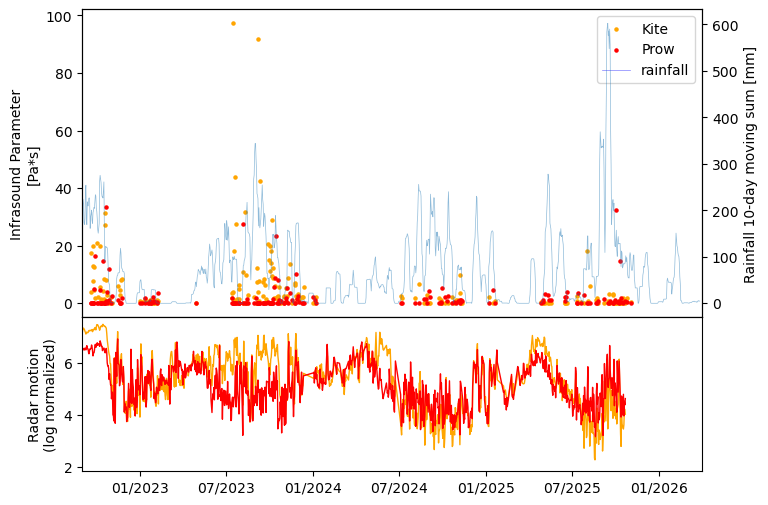

In [6]:
#Plot timeseries!
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

resample_window = "24h"
csvfile = "data/BA_RadarData_2026-04-14T05_01_58Z.csv"

def load_radar_data(csvfile=csvfile, resample_window=resample_window, zone=None, verbose=1):
    df = pd.read_csv(csvfile, parse_dates=[0])
    #print(df.columns.to_numpy())
    # shift from AKST to UTC time
    df["Timestamp"] = df["Timestamp"] + pd.Timedelta(hours=9)

    # Keep only 'AIM / mean' columns
    keepcols = ["Timestamp"]
    AIM_cols = [colname for colname in df.columns if "AIM" in colname]
    mean_cols = [colname for colname in AIM_cols if "mean" in colname]
    mean_cols.remove("AIM Stable area mean (15780)")  # remove stable area as well
    if zone is not None:
        mean_cols = [colname for colname in AIM_cols if zone in colname]
        print(mean_cols)
    keepcols.extend(mean_cols)
    print(keepcols)
    df = df[keepcols]
    df = df.dropna(how="any", axis=0)  # drop rows with missing data
    df = df.sort_values(by="Timestamp", ascending=True)
    df = df.set_index("Timestamp")
    # print(df.shape)
    

    # take the median for each column, in windows
    df_med = df.resample(resample_window, label="right").median()
    df_med = df_med.abs()  # take absolute value
    # ^here I thought that while most motion results in negative values,
    # some motion could result in positive values,
    # such as a block moving out of an roi and revealing the slope further behind it.

    # then just sum across all the columns:
    aim_motion = df_med.sum(axis=1)  # How to reconcile all the different points

    aim_motion = aim_motion.loc[aim_motion != 0]  # Drop zeros! important for log scaling
    aim_motion = np.log(aim_motion)
    
    return aim_motion

events = pd.read_csv("data/lts_events_2022_2026March_allmonths_wPressure.csv", parse_dates=[1,2])
print(events.shape)

daily = (
    events
    .assign(date=events['datetime_min'].dt.date)
    .groupby(['date', 'label_first'])['Infrasound_param']
    .sum()
    .unstack(fill_value=0)
    .rename(columns={
        'box1': 'box1_infrasound_parameter',
        'box2': 'box2_infrasound_parameter'
    })
    .reset_index()
)
fig, axs = plt.subplots(nrows=2, figsize=(8,6), gridspec_kw={'height_ratios':(2,1)})
ax=axs[0]
ax2 = ax.twinx()



#also import rainfall:
met_data_all = "/Users/che/Desktop/usgs/data/bae_metdata.csv"
met_data = pd.read_csv(met_data_all, parse_dates=[1], date_format='%m/%d/%y %H:%M')
print(met_data.columns)

daily_rainfall = (
    met_data
    .assign(date=met_data['timestamp'].dt.date)
    .groupby(['date'])['rain_mm_tot']
    .sum()
    .reset_index()
)
# convert date back to datetime for rolling
daily_rainfall['date'] = pd.to_datetime(daily_rainfall['date'])

# sort by date
daily_rainfall = daily_rainfall.sort_values('date')

# calculate 10-day moving sum (including current day)
daily_rainfall['rain_10day_sum'] = (
    daily_rainfall['rain_mm_tot']
    .rolling(window=10, min_periods=1)
    .sum()
)


ax2.plot(daily_rainfall['date'], daily_rainfall['rain_10day_sum'], label='rainfall',lw=0.5, alpha=0.5)

ax.scatter(daily['date'], daily['box1_infrasound_parameter'], label='Kite', c='orange', s=5)
ax.scatter(daily['date'], daily['box2_infrasound_parameter'], label='Prow', c='red', s=5)
ax.plot([], [], color='blue', lw=0.5, alpha=0.5, label='rainfall')

ax.set_ylabel("Infrasound Parameter\n[Pa*s]")
ax2.set_ylabel("Rainfall 10-day moving sum [mm]")
ax.set_xticks(())

ax.legend()

ax.set_xlim(pd.Timestamp("2022-09-01"), pd.Timestamp("2026-04-01"))

Kite_motion = load_radar_data(zone='Kite', verbose=0)
Prow_motion = load_radar_data(zone='Prow', verbose=0)
axs[1].plot(Kite_motion, c='orange', lw=1)
axs[1].plot(Prow_motion, c='red', lw=1)
axs[1].set_ylabel("Radar motion\n(log normalized)")

axs[1].set_xlim(pd.Timestamp("2022-09-01"), pd.Timestamp("2026-04-01"))
ticks = pd.date_range(start="2023-01-01", end="2026-01-01", freq="6MS")
axs[1].set_xticks(ticks)
axs[1].set_xticklabels([t.strftime("%m/%Y") for t in ticks])

plt.subplots_adjust(hspace=0)

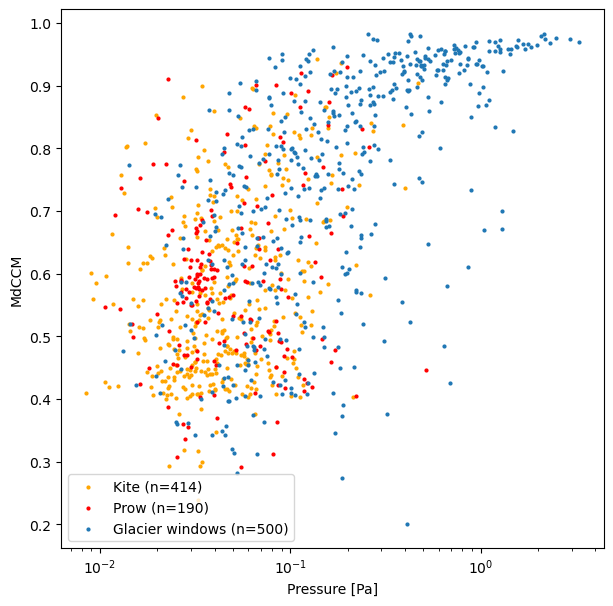

In [14]:
# Plot pressure and MdCCM for glacier windows and events

events = pd.read_csv("data/lts_events_2022_2026March_allmonths_wPressure.csv")

glacier_windows = pd.read_csv("data/500_glacier_windows_wPressure.csv")


fig,ax = plt.subplots(figsize=(7,7))

cs = ['Orange', 'Red']
lbs = ['Kite', 'Prow']
for i,label in enumerate(['box1', 'box2']):
    subevents = events.loc[events['label_first']==label]
    ax.scatter(subevents['Pressure'], subevents['MdCCM_max'], c=cs[i], s=4, label=f"{lbs[i]} (n={len(subevents)})")

ax.scatter(glacier_windows['Pressure'], glacier_windows['MdCCM'], s=4, label='Glacier windows (n=500)')
ax.set_xlabel('Pressure [Pa]')
ax.set_ylabel('MdCCM')
ax.legend()
ax.set_xscale('log')

677it [09:07,  1.24it/s]
500it [08:50,  1.06s/it]


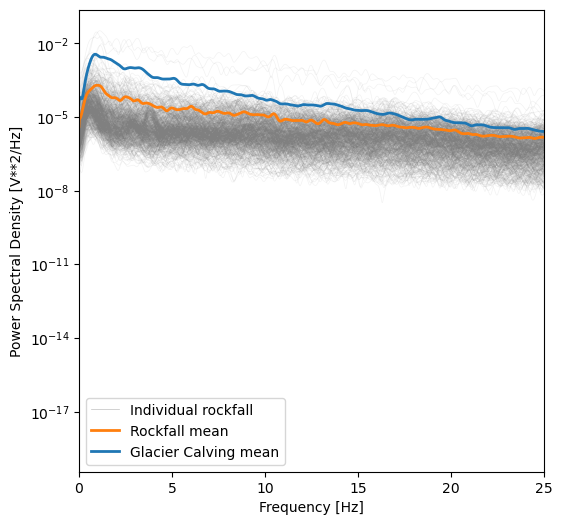

In [14]:
#Get PSD curves
from scipy.signal import welch
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from obspy.core import UTCDateTime as UTC
from obspy.clients.filesystem.sds import Client as SDS_Client
from obspy.clients.fdsn import Client as FDSN_Client

import warnings
from obspy.core.util.deprecation_helpers import ObsPyDeprecationWarning

warnings.filterwarnings("ignore", category=ObsPyDeprecationWarning)

def get_stream_from_local(
    network="AV",
    station="BAEI",
    location="*",
    channel="HDF",
    starttime=None,
    endtime=None,
    fmin=None,
    fmax=None,
    trim_fill_value=0,
    taper_length=2,
    detrend="linear",
    remove_response=True,
):

    # try:
    sds_client = SDS_Client("/Users/che/Documents/Landslides/datarepo/data")
    doy = starttime.julday
    #note, even though doy is static, multiple days can be requested and will work with this.
    fmt = "{network}/{year}/{doy:03d}/{station}.{network}.{year}.{doy:03d}"
    sds_client.FMTSTR = fmt
    st = sds_client.get_waveforms(
        network,
        station,
        location,
        channel,
        starttime,
        endtime,
    )
    #merge and trim first thing
    if trim_fill_value is not False:  # Helps ensure all traces are the same length
        st.merge(method=1, fill_value=trim_fill_value)  # merge first method=1 is overlap resolution
        st.trim(starttime, endtime, pad=True, fill_value=trim_fill_value)
    else:
        st.merge(method=1)  # at least merge even if not trimming

    if detrend is not None:
        st.detrend("linear")

    if taper_length is not None:
        st.taper(max_percentage=None, max_length=taper_length)

    if remove_response:  
        #Need tp get inventory in order to be able to remove response
        iris_client = FDSN_Client("IRIS")
        inv = iris_client.get_stations(network="AV", station="BAEI", level="response")

        # Remove full response (counts → Pascals if metadata is correct)
        st.remove_response(inventory=inv, pre_filt=[0.0005, 0.001, 48, 50], water_level=None) #pre-filt for 100Hz infrasound data


        # st.taper(max_percentage=None, max_length=1)
    if fmin is not None:
        if fmax is not None:
            st.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=2, zerophase=True)

    return st


def extract_psd(events_df, nperseg=500, t0_col='datetime_min', t1_col='datetime_max'):
    # store PSDs for averaging later
    psd_list = []
    freqs = None

    nfft = np.power(2, int(np.ceil(np.log2(nperseg))) + 3)  # Pad FFT
    sr = 100
    for _, row in tqdm(events_df.iterrows()):
        t0 = UTC(row[t0_col]) - 10
        t1 = UTC(row[t1_col]) + 10
        st = get_stream_from_local(starttime=t0,endtime=t1,detrend=True,fmin=0.5,fmax=30)
        if len(st) == 0:
            continue
        tr = st[5]
        x = tr.data
        if len(x) < nperseg:
            continue
        f, psd = welch(x, fs=sr, nperseg=nperseg, nfft=nfft)

        # save frequencies once
        if freqs is None:
            freqs = f
        psd_list.append(psd)
        psd_array = np.vstack(psd_list)
    return events_df, freqs, psd_array

events = pd.read_csv("/Users/che/Desktop/usgs/data/prelim_2022_2026March_events_allmonths_wPressure.csv")
events = events#.iloc[0:50]
events, f, psd_array = extract_psd(events)

# recreate plot from saved outputs
fig, ax = plt.subplots(figsize=(6, 6))
# plot all PSDs
for psd in psd_array:
    ax.plot(f, psd, color='gray', alpha=0.1, linewidth=0.5)
# plot mean PSD
ax.plot([], [], color='gray', alpha=0.5, linewidth=0.5, label="Individual rockfall")
mean_psd = np.mean(psd_array, axis=0)
ax.plot(f, mean_psd, color='tab:orange', linewidth=2, label='Rockfall mean')

gl = pd.read_csv("/Users/che/Desktop/usgs/data/500_glacier_windows_wPressure.csv")
gl = gl#.iloc[0:50]
gl, f, gpsd_array = extract_psd(gl, t0_col='datetime', t1_col='datetime')
#for psd in gpsd_array:
#    ax.plot(f, psd, color='tab:cyan', alpha=0.3, linewidth=0.5)
# plot mean PSD
gmean_psd = np.mean(gpsd_array, axis=0)
ax.plot(f, gmean_psd, color='tab:blue', linewidth=2, label='Glacier Calving mean')


ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Power Spectral Density [V**2/Hz]")
ax.set_xlim((0,25))
ax.set_yscale("log")
ax.legend()




10
Using 2D array processing as only lat and lon were provided.


c:\Users\csaunders-shultz\AppData\Local\miniforge3\envs\infresnel\Lib\site-packages\lts_array\classes\lts_classes.py:557: RuntimeWarning: invalid value encountered in scalar divide
  D = np.sqrt(foo + (a * b - 2 * c - a2 * a / 4) / R)
c:\Users\csaunders-shultz\AppData\Local\miniforge3\envs\infresnel\Lib\site-packages\lts_array\classes\lts_classes.py:558: RuntimeWarning: invalid value encountered in scalar divide
  E = np.sqrt(foo - (a * b - 2 * c - a2 * a / 4) / R)  # ...


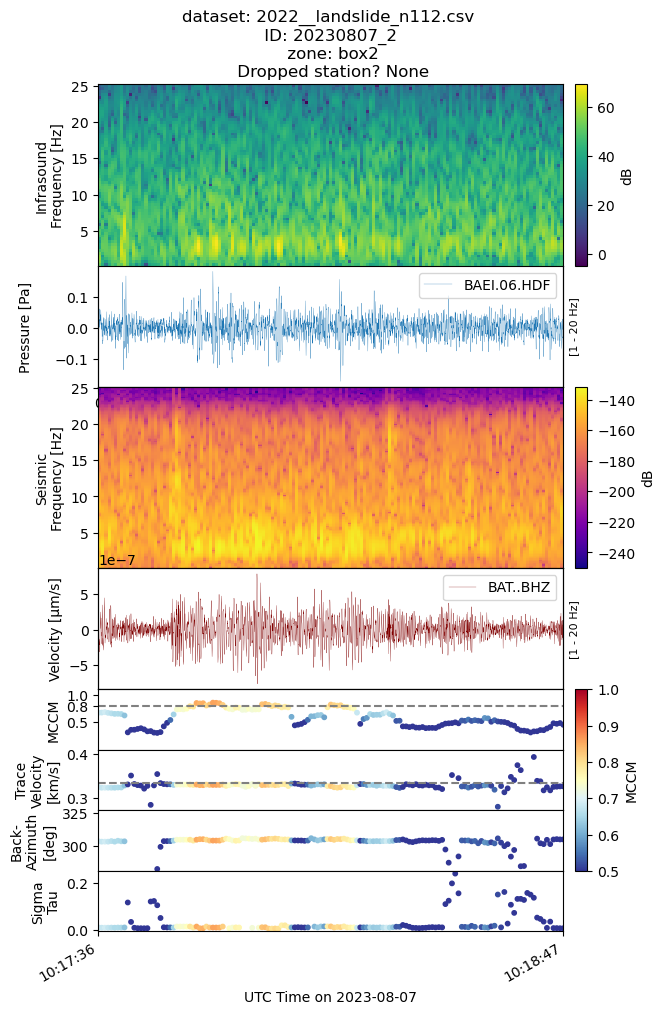

In [42]:
#Examine an actual event
from obspy.core import UTCDateTime as UTC
import infrasound_functions as func

#Now do LTS array processing:
import lts_array
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

def multi_plot(t0, t1, fmin=1, fmax=20):

    st = func.gather_and_clean(starttime=START, endtime=END, fmin=1, fmax=20)
    lat_list = [tr.stats.latitude for tr in st]
    lon_list = [tr.stats.longitude for tr in st]

    # print("Running LTS Array Processing ...")
    lts_vel, lts_baz, array_times, mccm, stdict, sigma_tau, conf_int_vel, conf_int_baz = (
        lts_array.ltsva(
            st=st,
            lat_list=lat_list,
            lon_list=lon_list,
            elev_list=None,
            window_length=5,  # Window length [sec]
            window_overlap=0.9,  # Window overlap decimal [0.0, 1.0)
            alpha=0.75,  # default. idk.
            plot_array_coordinates=False,
        )
    )
    dropped_station=func.interpret_stdict(stdict)

    plot_seismic=True
    if plot_seismic:
        bae = func.gather_and_clean(network='AK', station='BAT', channel='BHZ', starttime=START, endtime=END, fmin=1, fmax=20)
        fig, axs = plt.subplots(nrows=8, figsize=(6,11), gridspec_kw={'height_ratios':[3,2,3,2,1,1,1,1]})
    else:
        fig, axs = plt.subplots(nrows=6, figsize=(6,8), gridspec_kw={'height_ratios':[3,2,1,1,1,1]})
    fig.subplots_adjust(hspace=0)
    CMAP='RdYlBu_r'

    #PLOT SPECTROGRAM
    STATION='06'
    if dropped_station==6: #indicating station 06
        STATION='01' #Plot alternate station
    data = st.select(location=STATION)[0].data
    f,t,sxx = func.my_spectrogram(data, win_dur=1, overlap_rate=0.5, fs=100, scaling='db')
    sc = axs[0].pcolormesh(t,f,sxx)
    cbax = fig.add_axes([0.92, axs[0].get_position().y0, 0.02, axs[0].get_position().y1 - axs[0].get_position().y0])
    plt.colorbar(sc, cax=cbax, label="dB")
    axs[0].set_ylabel('Infrasound\nFrequency [Hz]')
    axs[0].spines['bottom'].set_visible(False)
    axs[1].spines['top'].set_visible(False)

    #PLOT WAVEFORM
    axs[1].plot(data, lw=0.2, label=f'BAEI.{STATION}.HDF')
    axs[1].set_xlim((0,len(data)))
    axs[1].set_ylabel('Pressure [Pa]\n')
    #axs[1].set_yticks((-1,-0.5,1,0.5,1))
    axs[1].legend()
    #add filter parameters
    ax_1 = axs[1].twinx()
    ax_1.set_yticks(())
    ax_1.set_ylabel(f"[{fmin} - {fmax} Hz]", size=8)

    #Plot Seismic!
    sss=0
    if plot_seismic:
        sss=2
        sdata= bae[0].data
        f,t,sxx = func.my_spectrogram(sdata, win_dur=1, overlap_rate=0.5, fs=50, scaling='db', db_ref_val=1)
        sc = axs[2].pcolormesh(t,f,sxx, cmap='plasma')
        cbax = fig.add_axes([0.92, axs[2].get_position().y0, 0.02, axs[2].get_position().y1 - axs[2].get_position().y0])
        plt.colorbar(sc, cax=cbax, label="dB")
        axs[2].set_ylabel('Seismic\nFrequency [Hz]')

        axs[3].plot(sdata, lw=0.2, c='maroon', label='BAT..BHZ')
        axs[3].set_xlim((0,len(sdata)))
        axs[3].set_ylabel('Velocity [µm/s]')
        axs[3].legend()
        ax_1 = axs[3].twinx()
        ax_1.set_yticks(())
        ax_1.set_ylabel(f"[{fmin} - {fmax} Hz]", size=8)


    # Plot mccm
    sc = axs[2+sss].scatter(array_times,mccm, c=mccm, s=10,
                        cmap=CMAP, label='MCCM', vmin=0.5, vmax=1)
    cbax = fig.add_axes([0.92, axs[4+sss].get_position().y0, 0.02, axs[2+sss].get_position().y1 - axs[4+sss].get_position().y0])
    plt.colorbar(sc, cax=cbax, label="MCCM")
    axs[2+sss].axhline(y=0.8, color='grey', linestyle='--')
    axs[2+sss].set_yticks((0.5,0.8,1))
    axs[2+sss].set_ylim(0,1.1)
    #axs[4].legend()
    axs[2+sss].set_ylabel("MCCM")

    #plot velocity
    axs[3+sss].scatter(array_times, lts_vel, c=mccm, s=10,
                    cmap=CMAP, label='Velocity', vmin=0.5, vmax=1)
    vel_mean, vel_std = np.nanmean(lts_vel), np.nanstd(lts_vel)
    axs[3+sss].set_ylim((vel_mean-vel_std, vel_mean+vel_std))
    axs[3+sss].axhline(y=0.334, color='grey', linestyle='--')
    axs[3+sss].set_ylabel('Trace\nVelocity\n[km/s]')

    #Plot back azimuth
    axs[4+sss].scatter(array_times, lts_baz, c=mccm, s=10,
                    cmap=CMAP, label='Azimuth', vmin=0.5, vmax=1)
    #if (np.min(baz)>=265) and (np.max(baz)<=355):
    az_mn, az_std = np.median(lts_baz), np.nanstd(lts_baz)
    axs[4+sss].set_ylim((az_mn-az_std, az_mn+az_std))
    #axs[4+sss].set_ylim(270,360)
    axs[4+sss].set_ylabel('Back-\nAzimuth\n[deg]')

    #Plot sigma tau

    axs[5+sss].scatter(array_times, sigma_tau, c=mccm, s=10,
                    cmap=CMAP, label='Sigma Tau', vmin=0.5, vmax=1)
    #if (np.min(baz)>=265) and (np.max(baz)<=355):
    #axs[5+sss].set_ylim(0,0.02)
    axs[5+sss].set_ylabel('Sigma\nTau')

    for i in [2,3,4,5]:
        axs[i+sss].set_xlim((array_times[0], array_times[-1]))

    for i in range(5):
        axs[i+sss].set_xticks(())

    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))  # Adjust format as needed

    # Set the locator for minutes with a 1-minute interval
    axs[-1].xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
    #axs[-1].xaxis.set_major_locator(mdates.SecondLocator(interval=20))

    # Rotate and right-align the x labels to avoid crowding
    for label in axs[-1].get_xticklabels(which='major'):
        label.set(rotation=30, horizontalalignment='right')
    axs[-1].set_xlabel(f"UTC Time on {START.date}")

    return fig, axs, dropped_station


events = pd.read_csv("data/lts_events_2022_2026March_allmonths_wPressure.csv", parse_dates=[1,2])

row = events.loc[ events['datetime_count'] == 10].iloc[1]
print(row.datetime_count)
START = UTC(row.datetime_min)-30
END = UTC(row.datetime_max)+10

fig, axs, ds = multi_plot(START, END)
axs[0].set_title(f"dataset: 2022__landslide_n112.csv \n ID: {row.event_id_} \n zone: {row.label_first}\n Dropped station? {ds}")
